# Facial Keypoint Detection baseline CNN y NaimishNet

Evalúa los tres modelos entrenados sobre frames que **nunca fueron usados** durante el entrenamiento:

- **Baseline CNN** (50k frames)
- **NaimishNet** (50k frames)
- **NaimishNet** (100k frames)

El test usa 10k frames del pool de 260k frames nunca vistos por ningún modelo.


## 1. Imports

In [1]:
import os
import pickle
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

try:
    import torch_directml
    device = torch_directml.device()
    print(f'Usando DirectML (AMD GPU): {device}')
except ImportError:
    device = torch.device('cpu')
    print('Usando CPU.')


Usando DirectML (AMD GPU): privateuseone:0


## 2. Configuración

In [ ]:
# Usar la ruta donde tienes los datos
DATA_DIR       = r'F:\DL_Project\Data'
INDEX_PATH     = os.path.join(DATA_DIR, 'preprocessed', 'frame_index.pkl')

# Rutas de los tres modelos
MODEL_BASELINE    = os.path.join(DATA_DIR, 'best_baseline_cnn.pth')
MODEL_NAIMISH_50K = os.path.join(DATA_DIR, 'naimishnet_50k.pth')
MODEL_NAIMISH_100K= os.path.join(DATA_DIR, 'naimishnet_100k.pth')

TRAIN_FRAMES_50K  = 50_000
TRAIN_FRAMES_100K = 100_000
TRAIN_SEED        = 42

TEST_FRAMES  = 10_000
TEST_SEED    = 99
IMG_SIZE     = 96
BATCH_SIZE   = 64
N_SHOW       = 8


## 3. Separar frames nuevos del índice

Reproducimos exactamente los 50k frames usados en entrenamiento (misma seed)
y cogemos el test de los frames **restantes**.


In [ ]:
print('Cargando índice')
with open(INDEX_PATH, 'rb') as f:
    index = pickle.load(f)
print(f'Frames totales en el índice: {len(index):,}')

random.seed(TRAIN_SEED)
train_indices_100k = set(random.sample(range(len(index)), min(TRAIN_FRAMES_100K, len(index))))

unseen_index = [index[i] for i in range(len(index)) if i not in train_indices_100k]
print(f'Frames excluidos (100k):  {len(train_indices_100k):,}')
print(f'Frames nunca vistos:      {len(unseen_index):,}')

# Seleccionar TEST_FRAMES del pool limpio
random.seed(TEST_SEED)
test_index = random.sample(unseen_index, min(TEST_FRAMES, len(unseen_index)))
print(f'Frames para test:         {len(test_index):,}')


Cargando índice...
Frames totales en el índice: 260,399
Frames usados en entrenamiento: 50,000
Frames nunca vistos:            210,399
Frames seleccionados para test: 10,000


## 4. Preprocesar frames de test

Como el test es solo 10k frames, los preprocesamos en memoria directamente.


In [4]:
test_images    = np.zeros((len(test_index), 3, IMG_SIZE, IMG_SIZE), dtype=np.float32)
test_keypoints = np.zeros((len(test_index), 136),                   dtype=np.float32)

for i, (npz_path, frame_idx, kps_norm) in enumerate(tqdm(test_index, desc='Preprocesando test')):
    data = np.load(npz_path, allow_pickle=True)
    img  = data['colorImages'][:, :, :, frame_idx]

    pil_img          = Image.fromarray(img)
    pil_img          = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.Resampling.BILINEAR)
    test_images[i]   = np.array(pil_img, dtype=np.float32).transpose(2, 0, 1) / 255.0
    test_keypoints[i] = kps_norm

print(f'\ntest_images:    {test_images.shape}')
print(f'test_keypoints: {test_keypoints.shape}')


Preprocesando test: 100%|██████████| 10000/10000 [15:09<00:00, 11.00it/s]


test_images:    (10000, 3, 96, 96)
test_keypoints: (10000, 136)


## 5. Dataset y DataLoader de test

In [5]:
class FacialKeypointDataset(Dataset):
    def __init__(self, images, keypoints):
        self.images    = torch.tensor(images,    dtype=torch.float32)
        self.keypoints = torch.tensor(keypoints, dtype=torch.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx], self.keypoints[idx]


test_dataset = FacialKeypointDataset(test_images, test_keypoints)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
print(f'Test: {len(test_dataset):,} frames  ({len(test_loader)} batches)')


Test: 10,000 frames  (157 batches)


## 6. Cargar modelo

In [6]:
class BaselineCNN(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2
        self.features = nn.Sequential(
            nn.Conv2d(3,   32, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32,  64, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(128,256, kernel_size=3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 1024), nn.ReLU(inplace=True),
            nn.Linear(1024, 256),          nn.ReLU(inplace=True),
            nn.Linear(256, out_dim),
            nn.Sigmoid(),
        )
    def forward(self, x):
        return self.regressor(self.features(x))


class NaimishNet(nn.Module):
    def __init__(self, num_keypoints=68):
        super().__init__()
        out_dim = num_keypoints * 2
        self.features = nn.Sequential(
            nn.Conv2d(3,  32, kernel_size=4), nn.BatchNorm2d(32), nn.ELU(), nn.MaxPool2d(2), nn.Dropout(0.1),
            nn.Conv2d(32, 64, kernel_size=3), nn.BatchNorm2d(64), nn.ELU(), nn.MaxPool2d(2), nn.Dropout(0.2),
            nn.Conv2d(64,128, kernel_size=2), nn.BatchNorm2d(128),nn.ELU(), nn.MaxPool2d(2), nn.Dropout(0.3),
            nn.Conv2d(128,256,kernel_size=1), nn.BatchNorm2d(256),nn.ELU(), nn.MaxPool2d(2), nn.Dropout(0.4),
        )
        with torch.no_grad():
            flat_sz = self.features(torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)).view(1,-1).shape[1]
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flat_sz, 1000), nn.ELU(), nn.Dropout(0.5),
            nn.Linear(1000, 1000),    nn.ELU(), nn.Dropout(0.5),
            nn.Linear(1000, out_dim),
        )
    def forward(self, x):
        return self.regressor(self.features(x))


def load_model(model_class, model_path, device):
    model = model_class()
    model.load_state_dict(torch.load(model_path, map_location='cpu'))
    model = model.to(device)
    model.eval()
    return model


def compute_rmse(model, loader, device, img_size=IMG_SIZE):
    all_gt, all_pred = [], []
    with torch.no_grad():
        for imgs, kps in loader:
            imgs = imgs.to(device)
            preds = model(imgs).cpu().numpy()
            all_gt.append(kps.numpy())
            all_pred.append(preds)
    all_gt   = np.concatenate(all_gt,   axis=0) * img_size
    all_pred = np.concatenate(all_pred, axis=0) * img_size
    diff     = (all_gt - all_pred).reshape(-1, 68, 2)
    return np.sqrt((diff ** 2).sum(axis=2)).mean(axis=0), np.sqrt((diff ** 2).sum(axis=2)).mean()


# Cargar los tres modelos
print('Cargando modelos...')
model_baseline    = load_model(BaselineCNN,  MODEL_BASELINE,     device)
model_naimish_50k = load_model(NaimishNet,   MODEL_NAIMISH_50K,  device)
model_naimish_100k= load_model(NaimishNet,   MODEL_NAIMISH_100K, device)
print('✅ Tres modelos cargados.')


C:\Users\manic\AppData\Local\Temp\ipykernel_15592\1173438294.py:24: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location='

Modelo cargado desde: F:\DL_Project\Data\best_baseline_cnn.pth ✅


## 7. RMSE en datos nuevos los tres modelos

RMSE global (datos nuevos): 0.90 px
RMSE mínimo (keypoint):     0.74 px  (kp #42)
RMSE máximo (keypoint):     1.23 px  (kp #16)


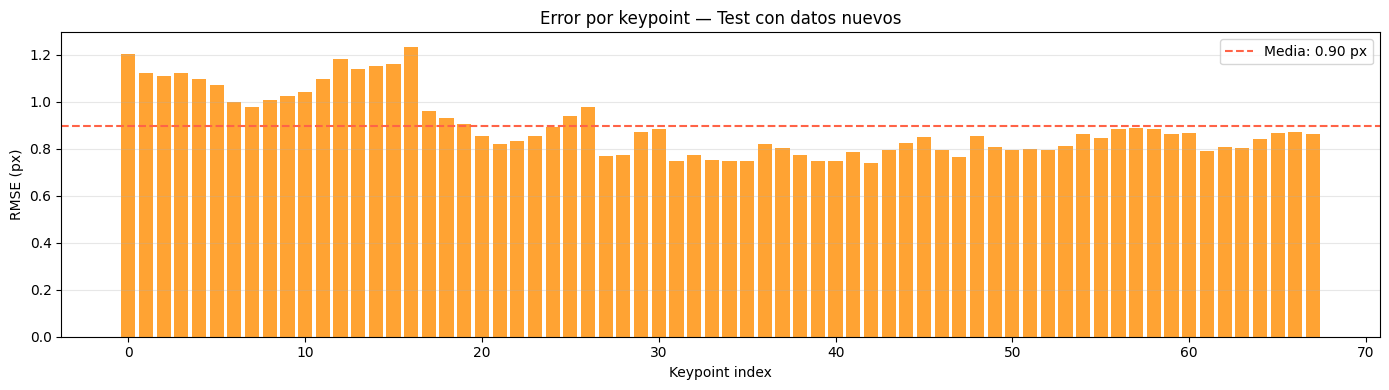

In [ ]:
# Baseline CNN
rmse_per_kp_base, rmse_base = compute_rmse(model_baseline, test_loader, device)
# NaimishNet 50k
rmse_per_kp_n50k, rmse_n50k = compute_rmse(model_naimish_50k, test_loader, device)
# NaimishNet 100k
rmse_per_kp_n100k,rmse_n100k= compute_rmse(model_naimish_100k, test_loader, device)

print(f'RMSE Baseline CNN  (50k):  {rmse_base:.2f} px')
print(f'RMSE NaimishNet    (50k):  {rmse_n50k:.2f} px')
print(f'RMSE NaimishNet    (100k): {rmse_n100k:.2f} px')

# Gráfico RMSE por keypoint tres modelos
fig, ax = plt.subplots(figsize=(14, 5))
x = range(68)
ax.bar([i - 0.25 for i in x], rmse_per_kp_base,  width=0.25, label=f'Baseline 50k  ({rmse_base:.2f} px)',  color='steelblue',  alpha=0.85)
ax.bar([i        for i in x], rmse_per_kp_n50k,  width=0.25, label=f'NaimishNet 50k  ({rmse_n50k:.2f} px)', color='darkorange', alpha=0.85)
ax.bar([i + 0.25 for i in x], rmse_per_kp_n100k, width=0.25, label=f'NaimishNet 100k ({rmse_n100k:.2f} px)',color='green',      alpha=0.85)
ax.axhline(rmse_base,  color='steelblue',  linestyle='--', linewidth=1)
ax.axhline(rmse_n50k,  color='darkorange', linestyle='--', linewidth=1)
ax.axhline(rmse_n100k, color='green',      linestyle='--', linewidth=1)
ax.set_xlabel('Keypoint index'); ax.set_ylabel('RMSE (px)')
ax.set_title('Error por keypoint — Test con datos nuevos')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Predicciones visuales comparativa

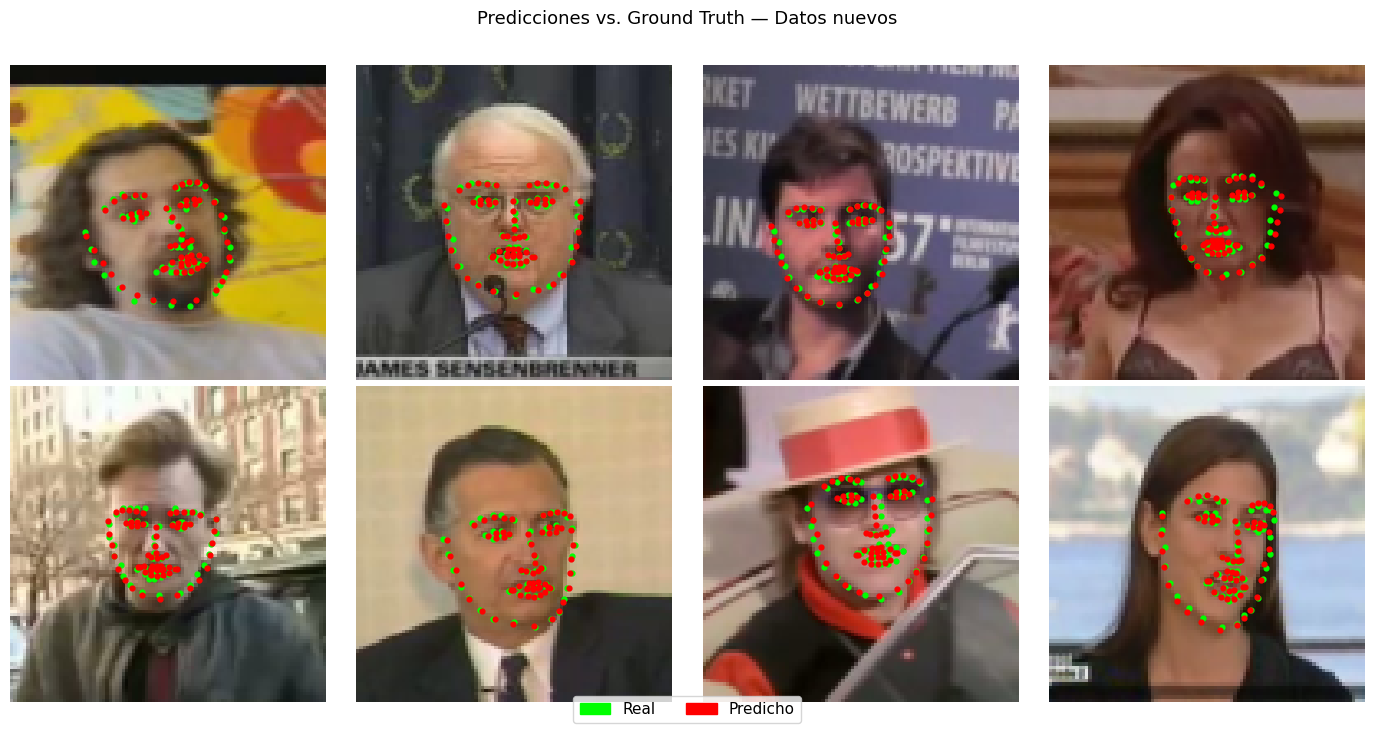

In [8]:
def show_predictions(model, loader, device, title, n=4, img_size=IMG_SIZE, clip=False):
    model.eval()
    imgs_b, kps_b = next(iter(loader))
    imgs_b = imgs_b.to(device)
    with torch.no_grad():
        preds_b = model(imgs_b).cpu().numpy()
    if clip:
        preds_b = np.clip(preds_b, 0, 1)

    imgs_np = imgs_b.cpu().numpy()[:n]
    kps_gt  = kps_b.numpy()[:n]
    kps_pred= preds_b[:n]

    fig, axes = plt.subplots(1, n, figsize=(n * 3.5, 3.5))
    for i in range(n):
        img  = imgs_np[i].transpose(1, 2, 0)
        gt   = kps_gt[i].reshape(-1, 2)   * img_size
        pred = kps_pred[i].reshape(-1, 2) * img_size
        axes[i].imshow(img)
        axes[i].scatter(gt[:,0],   gt[:,1],   s=12, c='lime', zorder=5)
        axes[i].scatter(pred[:,0], pred[:,1], s=12, c='red',  zorder=6)
        axes[i].axis('off')

    patch_gt   = mpatches.Patch(color='lime', label='Real')
    patch_pred = mpatches.Patch(color='red',  label='Predicho')
    fig.legend(handles=[patch_gt, patch_pred], loc='lower center', ncol=2,
               fontsize=10, bbox_to_anchor=(0.5, -0.05))
    plt.suptitle(title, fontsize=12, y=1.02)
    plt.tight_layout(); plt.show()


show_predictions(model_baseline,     test_loader, device, 'Baseline CNN (50k)')
show_predictions(model_naimish_50k,  test_loader, device, 'NaimishNet (50k)',  clip=True)
show_predictions(model_naimish_100k, test_loader, device, 'NaimishNet (100k)', clip=True)


## 9. Comparativa final

In [ ]:
val_rmse_baseline = 0.89   # del evaluate.ipynb

print('=' * 65)
print('COMPARATIVA FINAL Test con datos nuevos')
print('=' * 65)
print(f'{"Modelo":<25} {"Frames":<8} {"RMSE val (px)":<16} {"RMSE test (px)"}')
print('-' * 65)
print(f'{"Baseline CNN":<25} {"50k":<8} {val_rmse_baseline:<16.2f} {rmse_base:.2f}')
print(f'{"NaimishNet":<25} {"50k":<8} {"—":<16} {rmse_n50k:.2f}')
print(f'{"NaimishNet":<25} {"100k":<8} {"—":<16} {rmse_n100k:.2f}')
print('=' * 65)
print()
mejora_arq  = (rmse_base - rmse_n50k)  / rmse_base * 100
mejora_data = (rmse_base - rmse_n100k) / rmse_base * 100
print(f'Mejora por arquitectura (NaimishNet 50k vs Baseline 50k): {mejora_arq:+.1f}%')
print(f'Mejora total (NaimishNet 100k vs Baseline 50k):           {mejora_data:+.1f}%')


COMPARATIVA — Generalización del modelo
Conjunto             Frames     RMSE (px)
---------------------------------------------
Validación           10,000     0.89 px
Test (datos nuevos)  10,000     0.90 px

Diferencia: 0.8%
✅ El modelo generaliza bien a datos nuevos.
